# EMBER2024: exploratory data analysis

Run `python scripts/run_validation.py` and `python scripts/run_eda.py` from the project root first. This notebook only reads their generated reports and visualizes descriptive, deduplicated EDA metrics. It does not train a model or make final feature decisions.

In [1]:
%pip install seaborn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: pytorch-lightning 1.5.10 has a non-standard dependency specifier torch>=1.7.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Works whether Jupyter starts in project/ or project/notebooks/.
PROJECT_ROOT = next((candidate for candidate in (Path.cwd(), *Path.cwd().parents)
                     if (candidate / 'reports' / 'validation' / 'validation_summary.json').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate project/reports/validation/validation_summary.json. Run scripts/run_validation.py from the project root first.')
print(f'Using project root: {PROJECT_ROOT}')
validation_path = PROJECT_ROOT / 'reports' / 'validation' / 'validation_summary.json'
eda_dir = PROJECT_ROOT / 'reports' / 'eda'
with validation_path.open(encoding='utf-8') as handle:
    validation = json.load(handle)
with (eda_dir / 'eda_summary.json').open(encoding='utf-8') as handle:
    eda = json.load(handle)
metrics = pd.read_csv(eda_dir / 'eda_sample_metrics.csv')
sns.set_theme(style='whitegrid', context='notebook')
metrics.shape

Using project root: c:\Users\saiga\Documents\Master of AAI - Sandiego\AAI-540\project


(10000, 24)

## Dataset and class distribution
Validation counts cover all raw rows. The EDA sample removes repeated SHA-256 values before visualization.

C:\Users\saiga\AppData\Local\Temp\ipykernel_40076\2417036430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=class_counts, x='label', y='records', palette='Set2')


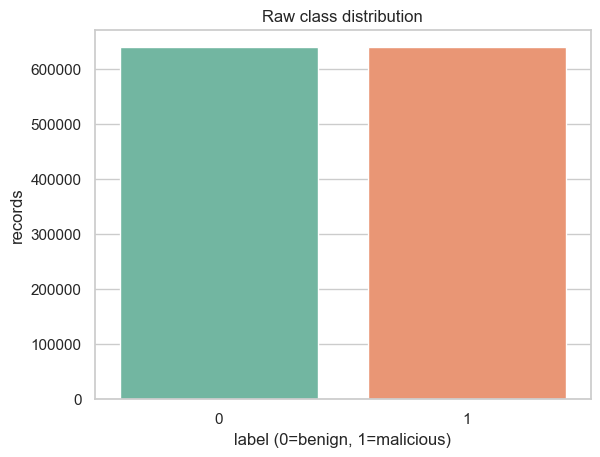

,test,train
0,240000,1040000


In [3]:
class_counts = pd.Series(validation['labels']['class_counts'], name='records').rename_axis('label').reset_index()
class_counts
ax = sns.barplot(data=class_counts, x='label', y='records', palette='Set2')
ax.set(title='Raw class distribution', xlabel='label (0=benign, 1=malicious)', ylabel='records')
plt.show()
pd.DataFrame([validation['records']['partition_counts']])

## Missingness and schema
Missingness below is calculated across the full validated raw dataset at the top-level JSON-field level.

In [4]:
missing = pd.DataFrame(validation['schema']['missingness']).T.reset_index(names='field')
missing['missing_rate'] = missing['missing_or_absent'] / validation['records']['valid_json_objects']
missing.sort_values('missing_rate', ascending=False).head(20)
plot_missing = missing[missing['missing_rate'] > 0].sort_values('missing_rate', ascending=False).head(20)
if not plot_missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_missing, y='field', x='missing_rate', color='steelblue')
    plt.title('Top-level fields with missing or absent values')
    plt.show()
pd.DataFrame(validation['schema']['field_type_counts']).T

,object,array,string,null,number,integer
authenticode,1280000.0,NaN,NaN,NaN,NaN,NaN
behavior,NaN,1280000.0,NaN,NaN,NaN,NaN
byteentropy,NaN,1280000.0,NaN,NaN,NaN,NaN
caps,NaN,1280000.0,NaN,NaN,NaN,NaN
datadirectories,NaN,1280000.0,NaN,NaN,NaN,NaN
detection_ratio,NaN,NaN,1280000.0,NaN,NaN,NaN
exploit,NaN,1280000.0,NaN,NaN,NaN,NaN
exports,NaN,1280000.0,NaN,NaN,NaN,NaN
family,NaN,NaN,508010.0,771990.0,NaN,NaN
family_confidence,NaN,NaN,NaN,771990.0,508010.0,NaN


## Benign/malicious feature distributions and outliers
These are descriptive metrics derived for EDA only. Log scaling makes heavy-tailed static-file measurements readable.

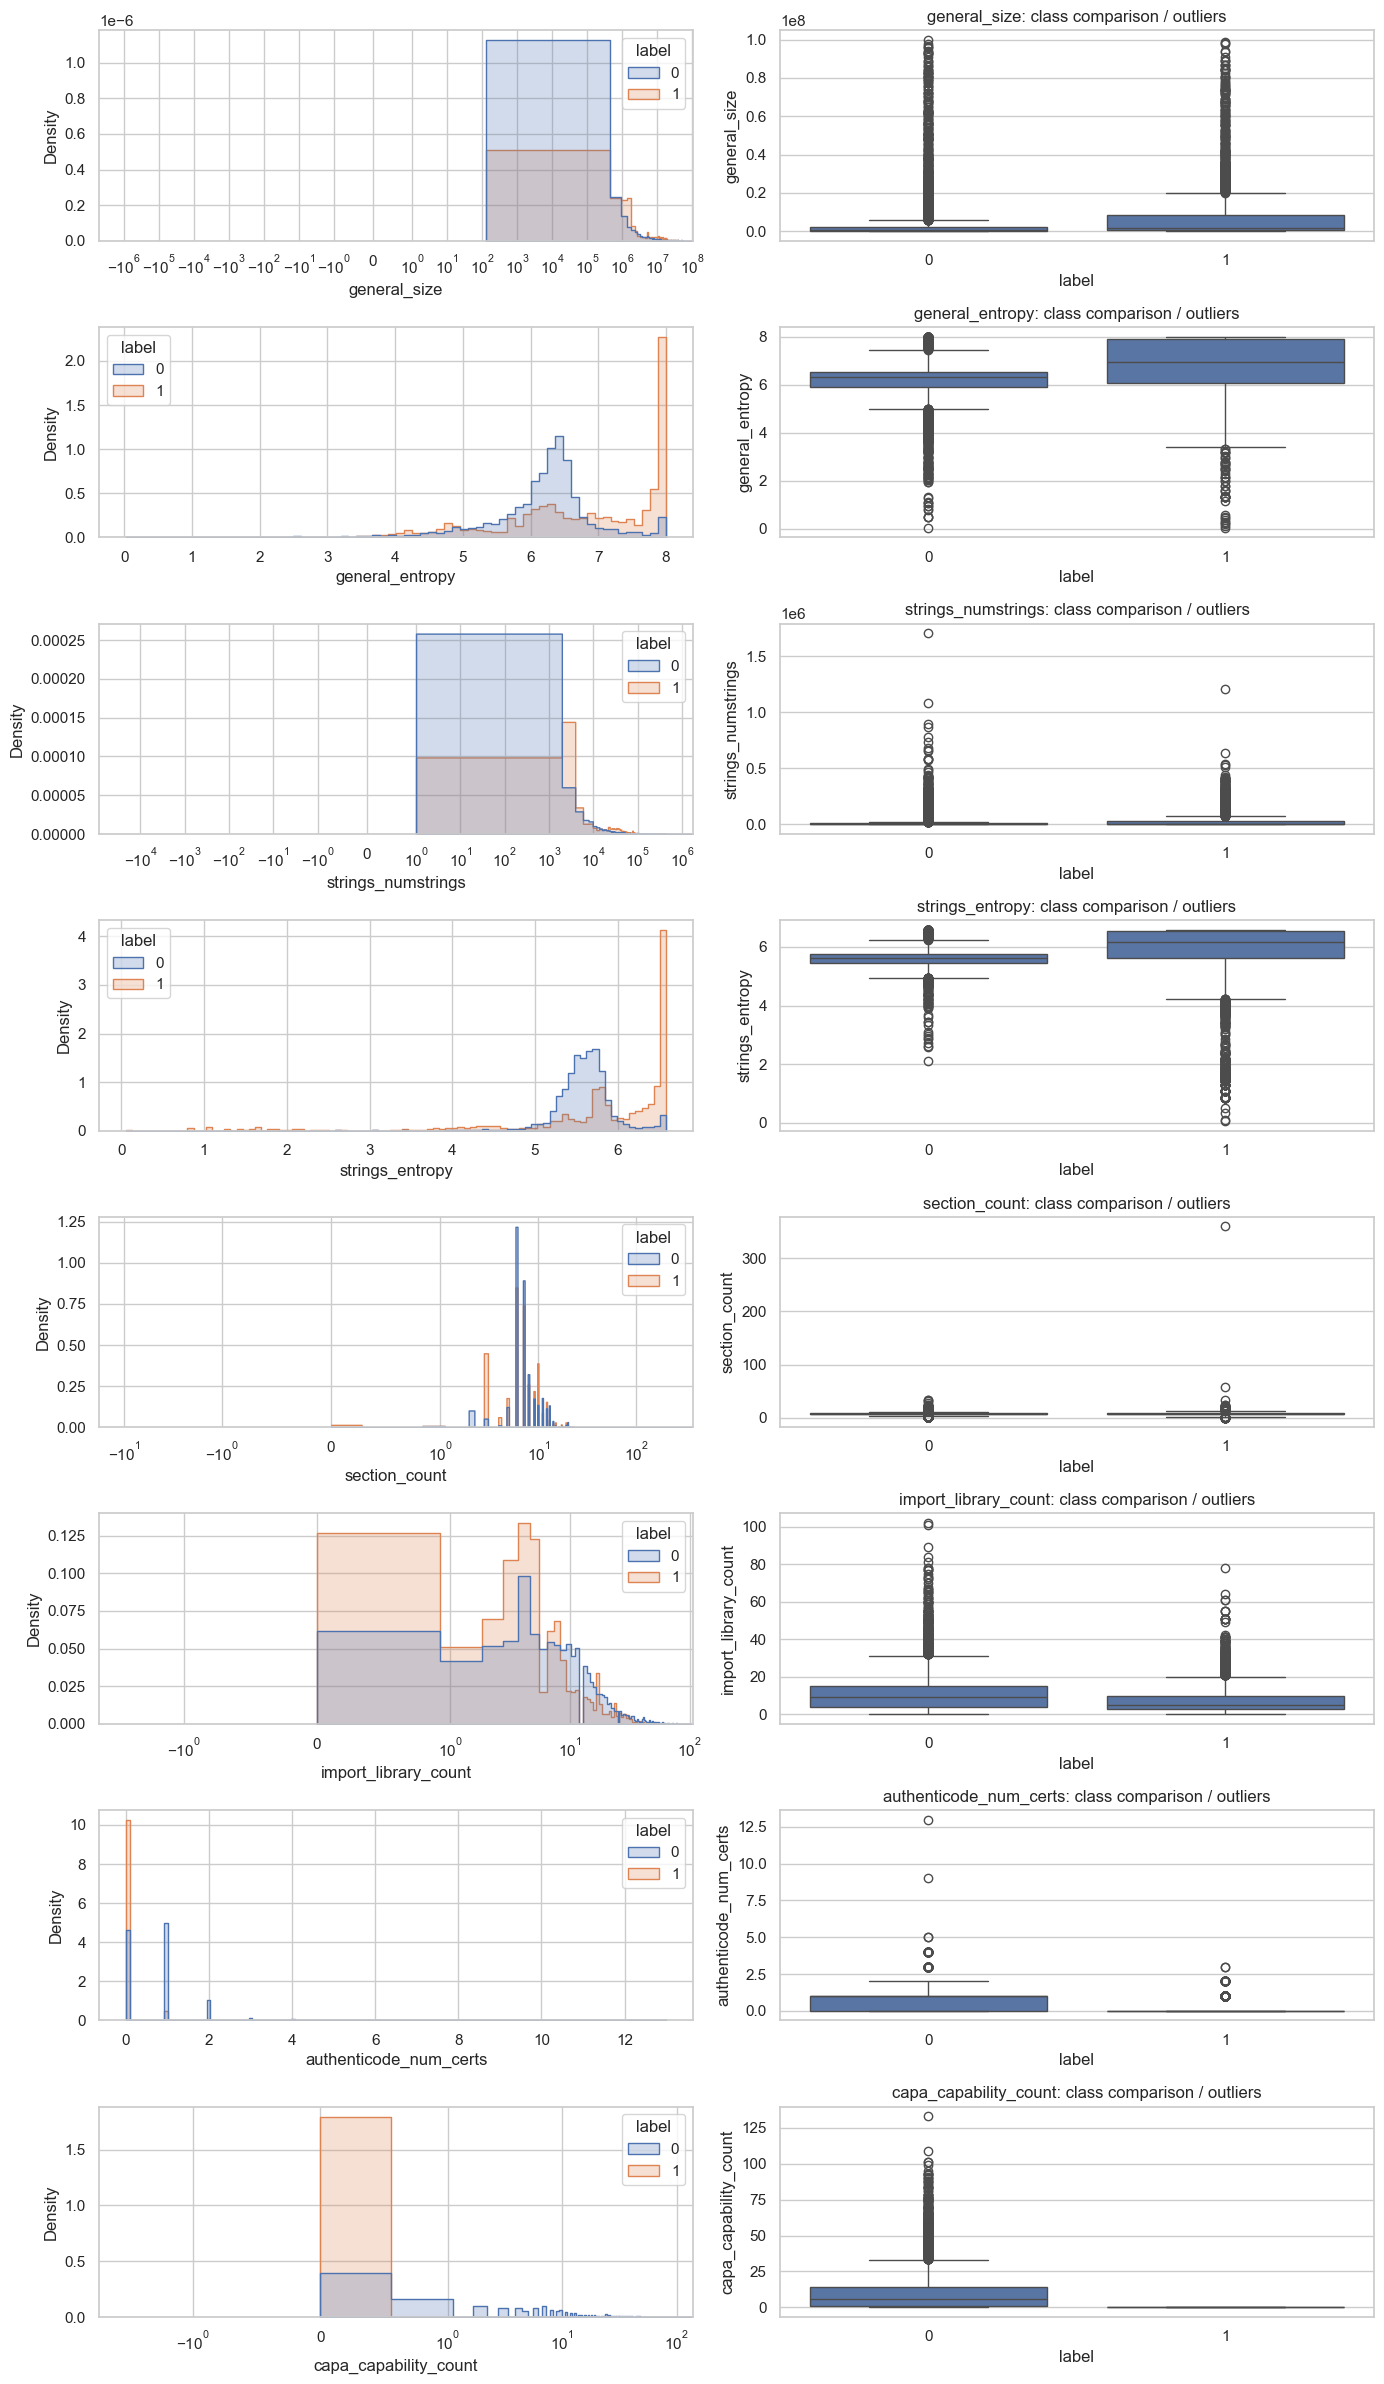

,count,minimum,p01,median,p99,maximum,mean,iqr,iqr_outlier_count
export_count,10000.0,0.000000e+00,0.000000e+00,0.000000e+00,5.103780e+03,1.864700e+04,1.736760e+02,3.000000e+00,1989.0
capa_ttp_count,10000.0,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,7.200000e+01,2.536800e+00,2.000000e+00,1375.0
capa_mbc_count,10000.0,0.000000e+00,0.000000e+00,0.000000e+00,5.401000e+01,1.000000e+02,5.079800e+00,5.000000e+00,1320.0
general_size,10000.0,1.340000e+02,1.126400e+04,1.028266e+06,6.802043e+07,9.983846e+07,5.482555e+06,4.875368e+06,1307.0
capa_capability_count,10000.0,0.000000e+00,0.000000e+00,0.000000e+00,6.100000e+01,1.330000e+02,5.696400e+00,6.000000e+00,1184.0
strings_numstrings,10000.0,1.000000e+00,7.500000e+01,3.352000e+03,3.107595e+05,1.705903e+06,2.464112e+04,2.104875e+04,1183.0
strings_avlength,10000.0,5.220150e+00,5.615370e+00,1.347273e+01,4.297502e+02,1.897008e+04,4.103685e+01,1.261410e+01,996.0
import_library_count,10000.0,0.000000e+00,0.000000e+00,7.000000e+00,4.800000e+01,1.020000e+02,9.616800e+00,1.000000e+01,521.0
strings_entropy,10000.0,5.780293e-02,1.561890e+00,5.736533e+00,6.583979e+00,6.584911e+00,5.693079e+00,8.016928e-01,448.0
section_count,9997.0,0.000000e+00,2.000000e+00,7.000000e+00,1.900000e+01,3.600000e+02,7.512254e+00,3.000000e+00,393.0


In [5]:
display_columns = ['general_size', 'general_entropy', 'strings_numstrings', 'strings_entropy', 'section_count', 'import_library_count', 'authenticode_num_certs', 'capa_capability_count']
available = [column for column in display_columns if column in metrics]
fig, axes = plt.subplots(len(available), 2, figsize=(14, max(4, 3 * len(available))))
for row, column in enumerate(available):
    series = metrics[[column, 'label']].dropna()
    sns.histplot(data=series, x=column, hue='label', stat='density', common_norm=False, element='step', ax=axes[row, 0])
    if series[column].min() >= 0 and series[column].max() / max(series[column].replace(0, pd.NA).min(), 1) > 100:
        axes[row, 0].set_xscale('symlog', linthresh=1)
    sns.boxplot(data=series, x='label', y=column, ax=axes[row, 1])
    axes[row, 1].set_title(f'{column}: class comparison / outliers')
plt.tight_layout()
plt.show()
pd.DataFrame(eda['numeric_distributions_and_outliers']).T.sort_values('iqr_outlier_count', ascending=False)

## Correlation and redundancy
Correlation is descriptive and calculated on the deduplicated EDA sample. High correlation is a review signal, not an automatic exclusion rule.

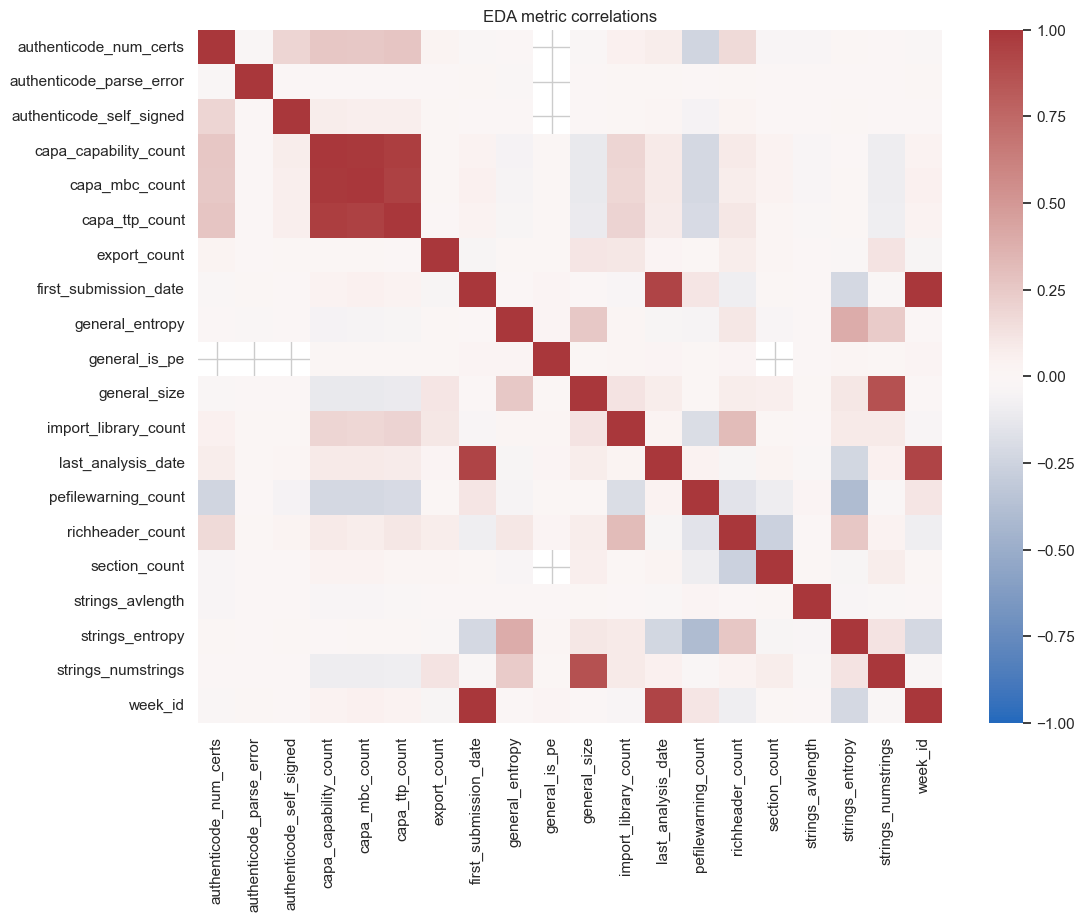

,left,right,n,pearson_r
0,first_submission_date,week_id,10000,0.999879
1,capa_capability_count,capa_mbc_count,10000,0.988504
2,capa_capability_count,capa_ttp_count,10000,0.968210
3,capa_mbc_count,capa_ttp_count,10000,0.951062
4,first_submission_date,last_analysis_date,10000,0.929861
5,last_analysis_date,week_id,10000,0.929775
6,general_size,strings_numstrings,10000,0.872756


In [6]:
numeric = metrics.select_dtypes(include='number').drop(columns=['label'], errors='ignore')
plt.figure(figsize=(12, 9))
sns.heatmap(numeric.corr(), cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('EDA metric correlations')
plt.show()
pd.DataFrame(eda['high_absolute_correlations']).head(25)

## Temporal view and leakage review
The official train/test weekly layout and `first_submission_date` were validated. The plot is descriptive; it must not override the supplied temporal partition. `last_analysis_date`, VirusTotal detection data, hashes, and taxonomy labels require exclusion or a documented inference-time availability decision.

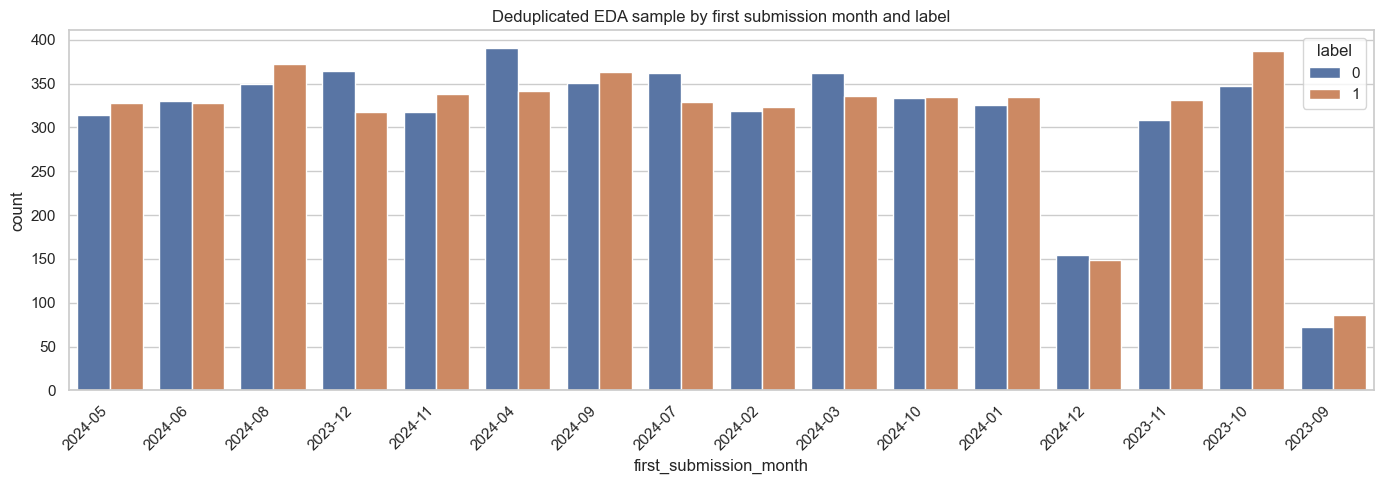

,0
identifier_fields_present,"[md5, sha1, sha256, tlsh]"
potential_leakage_or_inference_unavailable_fields_present,"[behavior, detection_ratio, exploit, family, f..."
temporal_fields_present,"[first_submission_date, last_analysis_date, we..."
note,Flags identify fields requiring review; they a...


In [7]:
temporal = metrics.dropna(subset=['first_submission_month']).copy()
plt.figure(figsize=(14, 5))
sns.countplot(data=temporal, x='first_submission_month', hue='label')
plt.xticks(rotation=45, ha='right')
plt.title('Deduplicated EDA sample by first submission month and label')
plt.tight_layout()
plt.show()
pd.DataFrame([validation['review_flags']]).T

## EDA conclusions for feature engineering

Read the generated conclusions below alongside the distribution and correlation tables. Any final include/exclude policy belongs to the next feature-engineering step, not this notebook.

In [8]:
for conclusion in eda['conclusions']:
    print('-', conclusion)
pd.DataFrame(eda['benign_malicious_comparison']).T

- EDA metrics are descriptive only and are not a final training feature list.
- Sampling removes repeated SHA-256 records before descriptive comparisons.
- Use the validation report's full-record missingness and class counts as authoritative; EDA missingness is sample-level.
- detection_ratio, taxonomy labels, and last_analysis_date remain leakage/inference-availability review fields, not EDA feature candidates.


,sample_size,numeric_medians
0,5000,"{'authenticode_num_certs': 1.0, 'authenticode_..."
1,5000,"{'authenticode_num_certs': 0.0, 'authenticode_..."


---
# Feature preparation

This section records the post-EDA feature-preparation policy used for the project submission. The implementation remains in `src/malware_data/feature_prep.py` and is invoked through `scripts/prepare_features.py`; this keeps the exact same pipeline available to the model-training teammate without requiring this notebook. No model is trained here.

## Feature policy

**Keep:** low-cardinality static PE aggregates from general file properties, strings, PE structure, PE parser warnings, and Authenticode.

**Transform:** apply `log1p` to count-like values, then standardize every feature with statistics fitted only on deduplicated official training records. Missing numeric values map to zero after train-mean standardization.

**Exclude:** target/taxonomy labels, hashes/identifiers, `detection_ratio`, timestamps and `week_id`, Capa fields, dynamic high-cardinality nested fields, and nearly constant `general.is_pe`. These exclusions prevent label/temporal/AV leakage and avoid inputs unavailable or impractical at static inference.

In [3]:
# Set to True only when you intend to create local processed CSV files.
# This streams the large raw dataset and can take substantial time.
RUN_FEATURE_PREPARATION = True

if RUN_FEATURE_PREPARATION:
    import subprocess
    import sys
    subprocess.run([sys.executable, 'scripts/prepare_features.py'], cwd=PROJECT_ROOT, check=True)
else:
    print('Feature preparation not run from this notebook. Run scripts/prepare_features.py, or set RUN_FEATURE_PREPARATION = True.')

## Final feature schema and model-training handoff

The final schema is the authoritative contract. It records exact feature names/order, raw-source paths, transformations, train-only fit statistics, missing-value policy, exclusions, and output-column roles. The training teammate must use only `model_feature_columns`; `record_id`, `label`, and `source_partition` are not model inputs.

In [4]:
schema_path = PROJECT_ROOT / 'data' / 'processed' / 'ember2024_win64_static_v1' / 'feature_schema.json'
if schema_path.is_file():
    with schema_path.open(encoding='utf-8') as handle:
        feature_schema = json.load(handle)
    schema_table = pd.DataFrame(feature_schema['fitted_features']).T
    display(schema_table[['source_path', 'base_transform', 'train_nonmissing_count', 'train_missing_count', 'train_mean', 'train_standard_deviation', 'constant_after_transform', 'rationale']])
    print('Model feature count:', feature_schema['model_feature_count'])
    print('Model feature order:', feature_schema['model_feature_columns'])
else:
    print(f'Feature schema not found yet: {schema_path}')

,source_path,base_transform,train_nonmissing_count,train_missing_count,train_mean,train_standard_deviation,constant_after_transform,rationale
general_size,"[general, size]",log1p,520000,0,13.675659,2.12058,False,Static file size; log reduces heavy tail.
general_entropy,"[general, entropy]",identity,520000,0,6.440525,1.131309,False,Static whole-file byte entropy.
strings_numstrings,"[strings, numstrings]",log1p,520000,0,8.345518,1.956733,False,Static printable-string count; log reduces hea...
strings_avlength,"[strings, avlength]",identity,520000,0,49.899279,1601.372984,False,Static average printable-string length.
strings_printables,"[strings, printables]",log1p,520000,0,11.065971,1.976882,False,Static printable-character count; log reduces ...
strings_entropy,"[strings, entropy]",identity,520000,0,5.781299,0.596888,False,Static printable-string entropy.
section_count,"[section, sections]",log1p,519934,66,2.077149,0.368249,False,Count of PE sections.
import_library_count,[imports],log1p,520000,0,1.970477,0.95733,False,"Count of imported library keys, not library na..."
export_count,[exports],log1p,520000,0,1.228236,2.075274,False,Count of exported symbols.
richheader_count,[richheader],log1p,520000,0,2.33478,1.4433,False,Count of Rich-header values.


Model feature count: 13
Model feature order: ['general_size', 'general_entropy', 'strings_numstrings', 'strings_avlength', 'strings_printables', 'strings_entropy', 'section_count', 'import_library_count', 'export_count', 'richheader_count', 'pefilewarning_count', 'authenticode_num_certs', 'authenticode_self_signed']


In [5]:
processing_report_path = schema_path.parent / 'processing_report.json'
if processing_report_path.is_file():
    with processing_report_path.open(encoding='utf-8') as handle:
        processing_report = json.load(handle)
    display(pd.DataFrame(processing_report['partitions']).T)
else:
    print('Processing report not found yet. It is created by scripts/prepare_features.py.')

,rows_read,rows_written,within_partition_duplicates_skipped
train,1040000,520000,520000
test,240000,119993,120007


---
# Final temporal datasets for model-training handoff

EMBER2024 provides an official 52-week train partition followed by a 12-week test partition. The course 40/10/10/40 ratio conflicts with retaining that published temporal boundary. The project therefore uses the documented hybrid chronology: 40 official-train weeks for training, 12 official-train weeks for validation, the first 6 official-test weeks for testing, and the newest 6 official-test weeks as a reserved production holdout.

| Split | Date range | Source partition | Purpose |
|---|---|---|---|
| Train | 2023-09-24 to 2024-06-29 | official train | Future model fitting |
| Validation | 2024-06-30 to 2024-09-21 | official train | Future selection/threshold work |
| Test | 2024-09-22 to 2024-11-02 | official test | Unseen newer-threat evaluation |
| Reserved production | 2024-11-03 to 2024-12-14 | official test | Final untouched newest-time evaluation |

All splits are disjoint after SHA-256 deduplication. This subdivides the official test partition, so results must be described as an **official-test-derived temporal test subset**, not an evaluation on the untouched full official EMBER2024 test set.

In [7]:
# Run only after the earlier Feature Preparation section has generated the prepared feature CSV files.
# This creates the four temporal handoff splits; it never changes raw EMBER2024 files.
RUN_TEMPORAL_SPLIT_CREATION = False

if RUN_TEMPORAL_SPLIT_CREATION:
    import subprocess
    import sys
    subprocess.run([sys.executable, 'scripts/create_temporal_splits.py'], cwd=PROJECT_ROOT, check=True)
else:
    print('Temporal split creation not run from notebook. Run scripts/create_temporal_splits.py, or set RUN_TEMPORAL_SPLIT_CREATION = True.')

In [8]:
split_root = PROJECT_ROOT / 'data' / 'processed' / 'ember2024_win64_static_v1' / 'temporal_splits_v1'
manifest_path = split_root / 'split_manifest.json'
if manifest_path.is_file():
    with manifest_path.open(encoding='utf-8') as handle:
        split_manifest = json.load(handle)
    split_summary = pd.DataFrame({
        name: {
            'rows': details['row_count'],
            'class_distribution': details['class_distribution'],
            'source_partitions': details['source_partition_counts'],
            'window': details['configured_window'],
            'schema_version': details['feature_schema']['version'],
        }
        for name, details in split_manifest['splits'].items()
    }).T
    display(split_summary)
    print(split_manifest['official_partition_note'])
else:
    print(f'Split manifest not found yet: {manifest_path}')

,rows,class_distribution,source_partitions,window,schema_version
train,400000,"{'0': 200000, '1': 200000}",{'train': 400000},"{'start_week': '2023-09-24', 'end_week': '2024...",ember2024_win64_static_v1
validation,120000,"{'0': 60000, '1': 60000}",{'train': 120000},"{'start_week': '2024-06-30', 'end_week': '2024...",ember2024_win64_static_v1
test,59995,"{'0': 29995, '1': 30000}",{'test': 59995},"{'start_week': '2024-09-22', 'end_week': '2024...",ember2024_win64_static_v1
reserved_production,59998,"{'0': 29998, '1': 30000}",{'test': 59998},"{'start_week': '2024-11-03', 'end_week': '2024...",ember2024_win64_static_v1


The official test partition is deliberately divided into test and reserved production. Do not claim an evaluation on the untouched full official EMBER2024 test partition.


## Submission conclusion

The raw Kaggle copy contains substantial repeated SHA-256 records, so validation, EDA sampling, and feature preparation explicitly deduplicate. The provided train/test temporal partition is preserved; test hashes already observed in train are excluded from prepared test output. The resulting schema and CSV files are versioned local artifacts suitable for the model-training team and for a later S3 upload.